# Heart Disease Classification — Analysis Notebook

Step-by-step ML pipeline with inline visualizations. This notebook mirrors `heart_disease.py` but in exploratory format, explaining each decision and showing outputs at every stage.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('data/heart.csv')
df.replace('?', float('nan'), inplace=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['target'] = (df['target'] > 0).astype(int)

print(f'Shape: {df.shape}')
print(f'Class balance: {df.target.value_counts().to_dict()} (0=healthy, 1=disease)')
missing = df.isnull().sum()
print(f'Missing values: {missing[missing > 0].to_dict()}')
df.head()

Shape: (303, 14)
Class balance: {0: 164, 1: 139} (0=healthy, 1=disease)
Missing values: {'ca': 4, 'thal': 2}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Exploratory Data Analysis

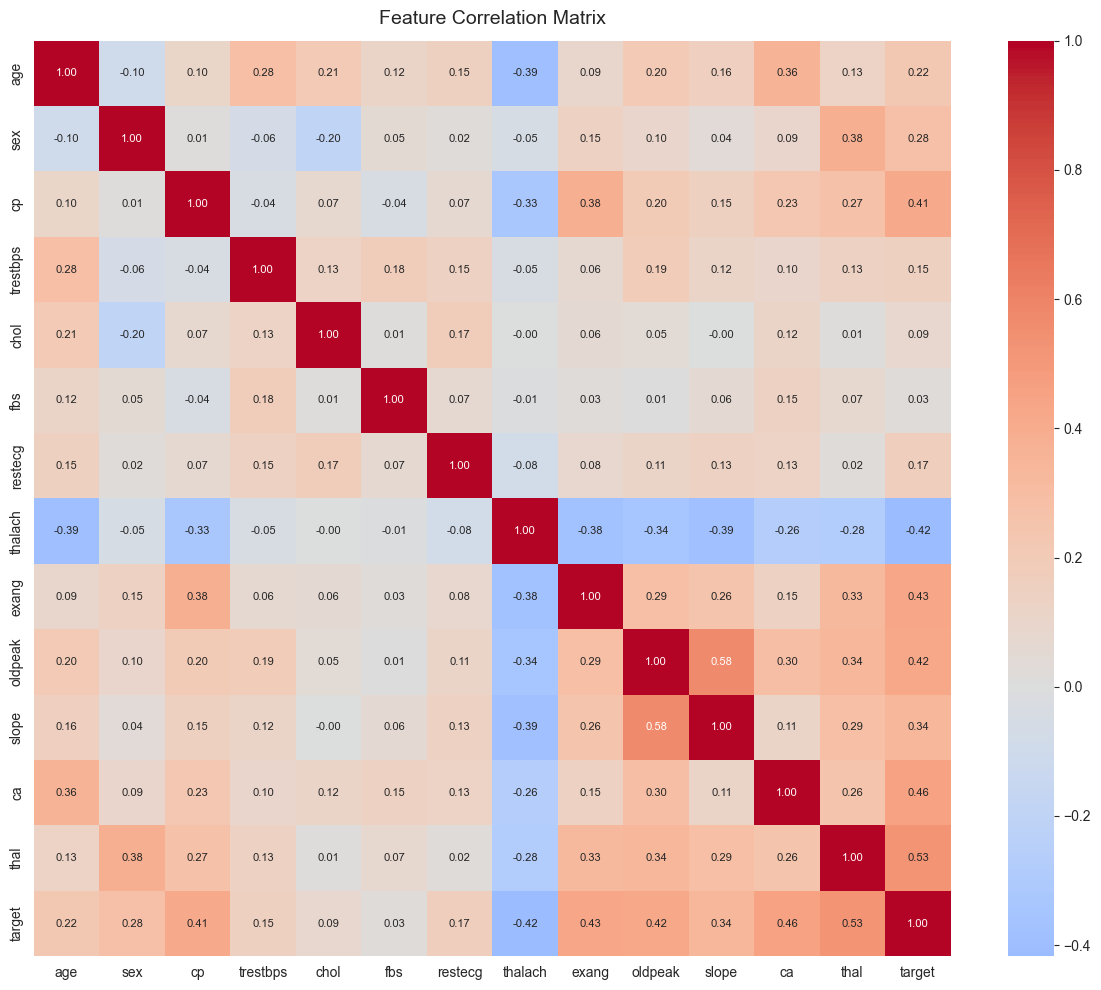

In [3]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

`target` shows the strongest correlations with `cp` (chest pain type), `thalach` (max heart rate achieved), `oldpeak` (ST depression), and `ca` (major vessels colored by fluoroscopy). This aligns with established cardiovascular risk factors.

## 3. Feature Engineering

Three interaction features grounded in clinical reasoning. We measure their impact on CV accuracy before deciding whether to use them.

In [4]:
X_raw = df.drop('target', axis=1)
y = df['target']

X_eng = X_raw.copy()
X_eng['age_thalach_ratio'] = X_eng['age'] / (X_eng['thalach'] + 1e-5)
X_eng['chest_pain_exang'] = X_eng['cp'] * X_eng['exang']
X_eng['oldpeak_slope'] = X_eng['oldpeak'] * (X_eng['slope'] + 1)

def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler()), ('clf', clf)])

cv = StratifiedKFold(5, shuffle=True, random_state=42)
rf = RandomForestClassifier(100, random_state=42)

base_cv = cross_val_score(make_pipe(rf), X_raw, y, cv=cv, scoring='accuracy')
eng_cv  = cross_val_score(make_pipe(rf), X_eng, y, cv=cv, scoring='accuracy')

print(f'Without engineering: {base_cv.mean():.4f} +/- {base_cv.std():.4f}')
print(f'With engineering:    {eng_cv.mean():.4f} +/- {eng_cv.std():.4f}  ({(eng_cv.mean()-base_cv.mean())*100:+.1f}%)')
X = X_raw if eng_cv.mean() <= base_cv.mean() else X_eng
print(f'Using: {"engineered" if X is X_eng else "original"} features')

Without engineering: 0.8447 +/- 0.0456
With engineering:    0.8381 +/- 0.0363  (-0.7%)
Using: original features


## 4. Model Comparison

Five models including a majority-class baseline. The baseline predicts the most common class every time — a model that cannot beat it by a meaningful margin has not learned anything useful from the data.

In [5]:
models = [
    ('Baseline (Majority)', DummyClassifier(strategy='most_frequent')),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Support Vector Machine', SVC(probability=True, random_state=42)),
]

results = []
baseline_score = None
for name, clf in models:
    scores = cross_val_score(make_pipe(clf), X, y, cv=cv, scoring='accuracy')
    results.append({'Model': name, 'Mean Accuracy': scores.mean(), 'Std': scores.std()})
    if name == 'Baseline (Majority)':
        baseline_score = scores.mean()

results_df = pd.DataFrame(results)
results_df['vs Baseline'] = results_df['Mean Accuracy'].apply(
    lambda m: f'+{(m-baseline_score)*100:.1f}%' if m != baseline_score else '---'
)
results_df.sort_values('Mean Accuracy', ascending=False).reset_index(drop=True)

,Model,Mean Accuracy,Std,vs Baseline
0,Random Forest,0.844699,0.045598,+30.3%
1,Support Vector Machine,0.838087,0.039000,+29.7%
2,Logistic Regression,0.831585,0.049559,+29.0%
3,K-Nearest Neighbors,0.821803,0.026207,+28.1%
4,Baseline (Majority),0.541257,0.005281,---


## 5. Best Model — Detailed Evaluation

              precision    recall  f1-score   support

     Healthy       0.96      0.82      0.89        33
     Disease       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



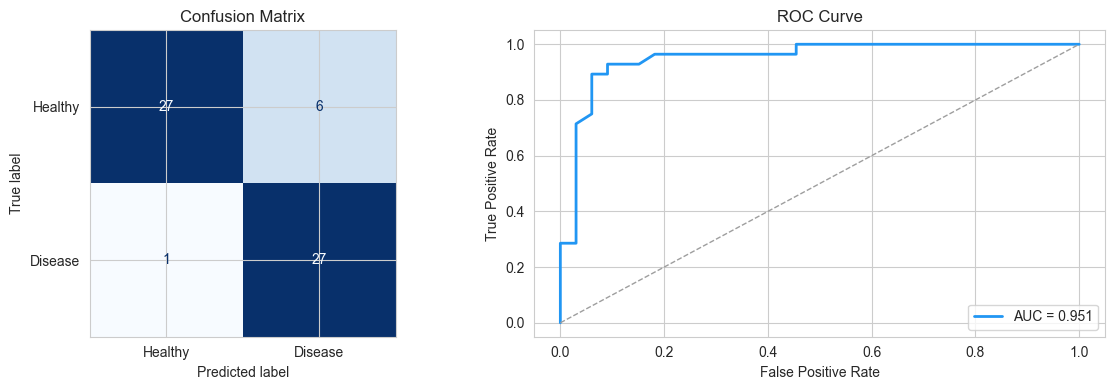

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
best_pipe = make_pipe(RandomForestClassifier(100, random_state=42))
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Disease']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'--',color='#9E9E9E',lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance

Random Forest importance can over-rank high-cardinality features (more splits = higher importance even if irrelevant). Permutation importance is model-agnostic — it measures the actual accuracy drop when each feature is randomly shuffled, making it a more honest signal.

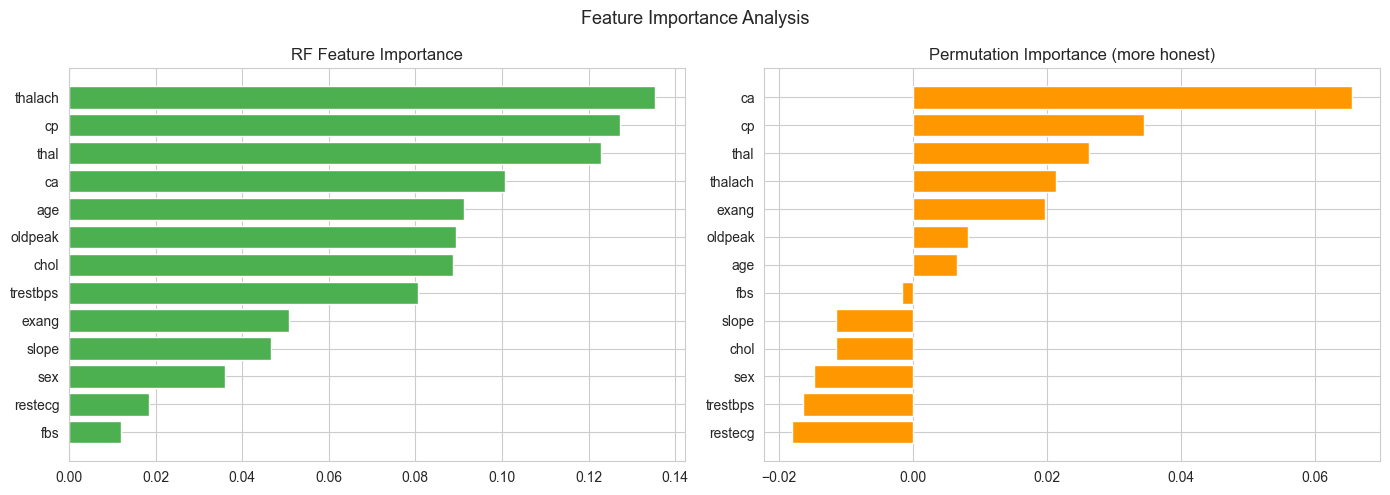

In [7]:
feat_names = list(X.columns)
rf_clf = best_pipe.named_steps['clf']
rf_imp = pd.Series(rf_clf.feature_importances_, index=feat_names).sort_values()

perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=feat_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(rf_imp.index, rf_imp.values, color='#4CAF50')
axes[0].set_title('RF Feature Importance')
axes[1].barh(perm_imp.index, perm_imp.values, color='#FF9800')
axes[1].set_title('Permutation Importance (more honest)')
plt.suptitle('Feature Importance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Learning Curve

Answers: *would more patient data help?*  
A wide training-CV gap signals variance — more data would narrow the gap.  
A narrow gap with low scores signals bias — a different model architecture is needed.

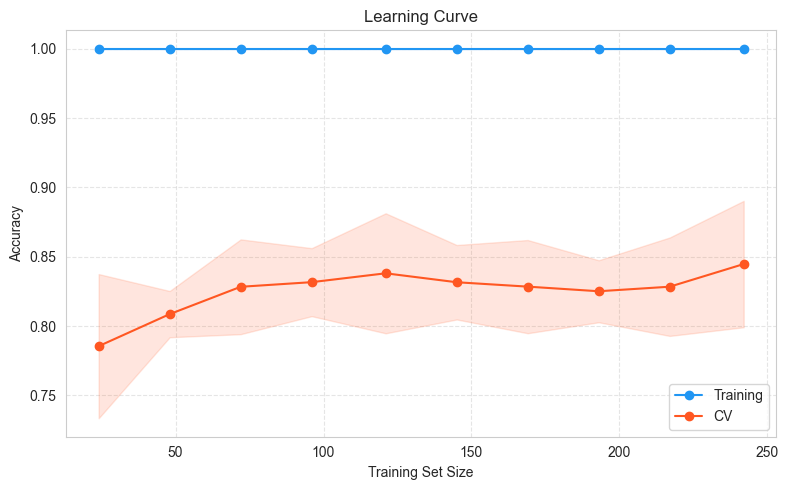

In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    scoring='accuracy', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(1), 'o-', color='#2196F3', label='Training')
ax.plot(train_sizes, val_scores.mean(1),   'o-', color='#FF5722', label='CV')
ax.fill_between(train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1), alpha=0.15, color='#2196F3')
ax.fill_between(train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#FF5722')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve'); ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions. Each dot is one patient; red = high feature value, blue = low; x-position shows whether that feature pushed the prediction toward or away from disease. SHAP is the standard for explainable ML in production medical AI systems.

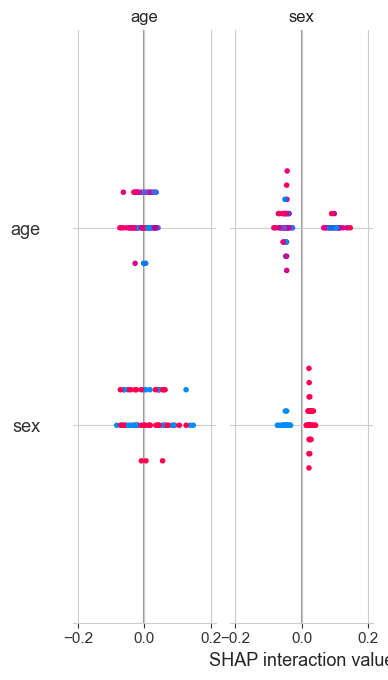

In [9]:
import shap

imputer = best_pipe.named_steps['imputer']
scaler  = best_pipe.named_steps['scaler']
X_transformed = scaler.transform(imputer.transform(X_test))

explainer   = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_transformed)
vals = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(vals, X_transformed, feature_names=feat_names, plot_type='dot')

The SHAP plot confirms what cardiology tells us: high ST depression (`oldpeak`), asymptomatic chest pain (`cp=3`), low max heart rate, and high vessel count (`ca`) are the strongest positive predictors. The model has learned real clinical relationships, not dataset artifacts.